# Model Analysis

This notebook focuses on:
- Feature importance analysis
- Understanding the influence of features on model predictions using the SHAP library
- Analysis of instances where the model makes incorrect predictions

The previous notebook related to modeling can be found here: https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/03_modeling.ipynb


## Notebook initialization

In [1]:
# Notebook initialization
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# print("Project root:", ROOT)

## Imports & Load Data

This analysis includes:
- The two best-performing models based on F1 score from the modeling stage: XGBoost and Random Forest
- A non–tree-based model (Logistic Regression) to provide a comparison with the top-performing tree-based models

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import joblib
from src.config import MODELS_DIR
from src.data import load_raw_data

pipeline_xgb = joblib.load(MODELS_DIR / "xgb_model_pipeline.joblib")
pipeline_rforest = joblib.load(MODELS_DIR / "random_forest_model_pipeline.joblib")
pipeline_logreg = joblib.load(MODELS_DIR / "log_reg_model_pipeline.joblib")

raw_df = load_raw_data()
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Split Data Train & Validation

In [3]:
from src.data import split_train_val, split_X_y

target_col = "y"

train_df, val_df = split_train_val(raw_df, stratify_col=target_col)

X_train, X_val, y_train, y_val = split_X_y(train_df, val_df, target_col)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((32950, 20), (8238, 20), (32950,), (8238,))

## Models Feature Importance

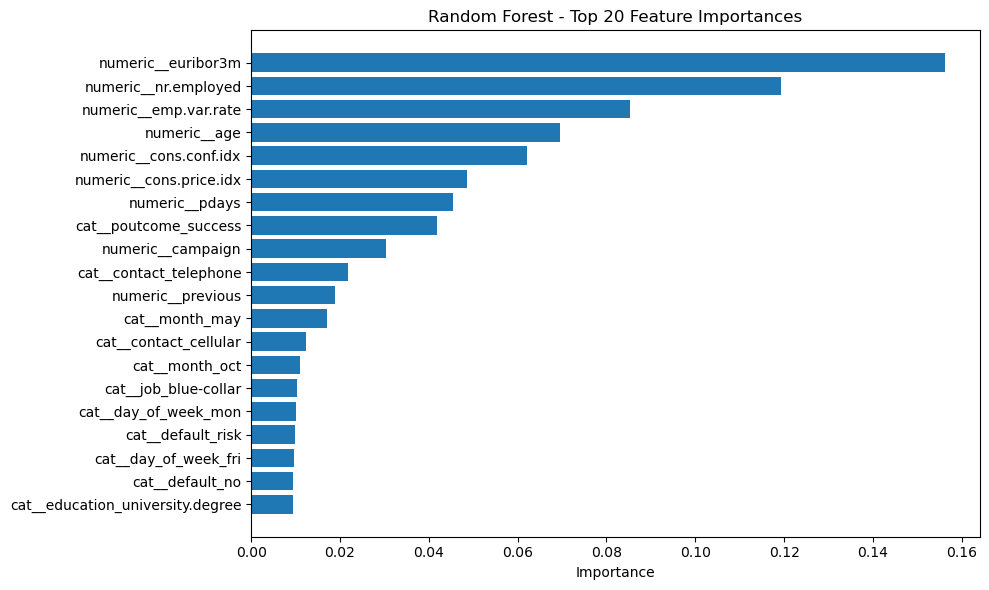

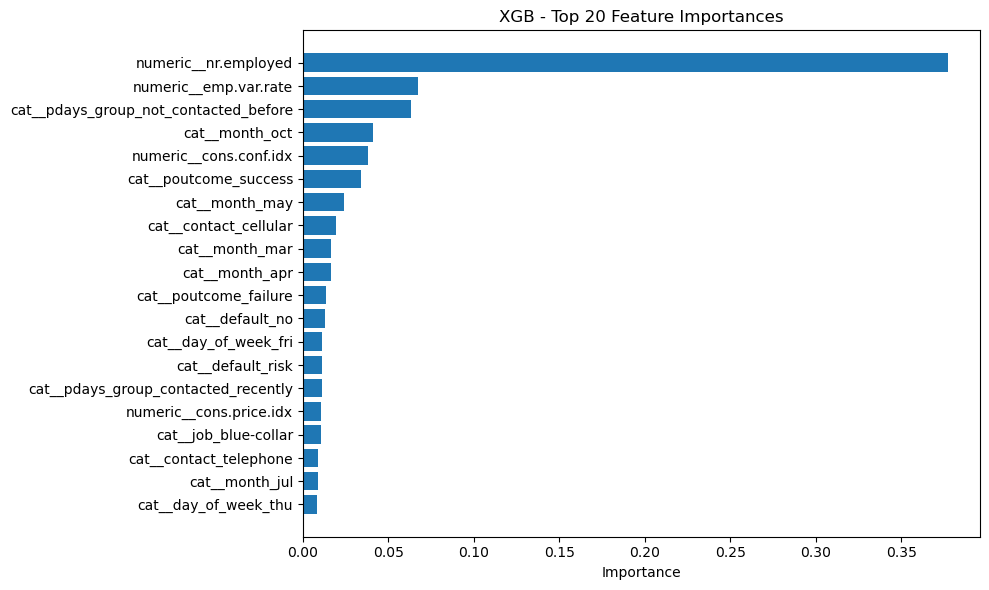

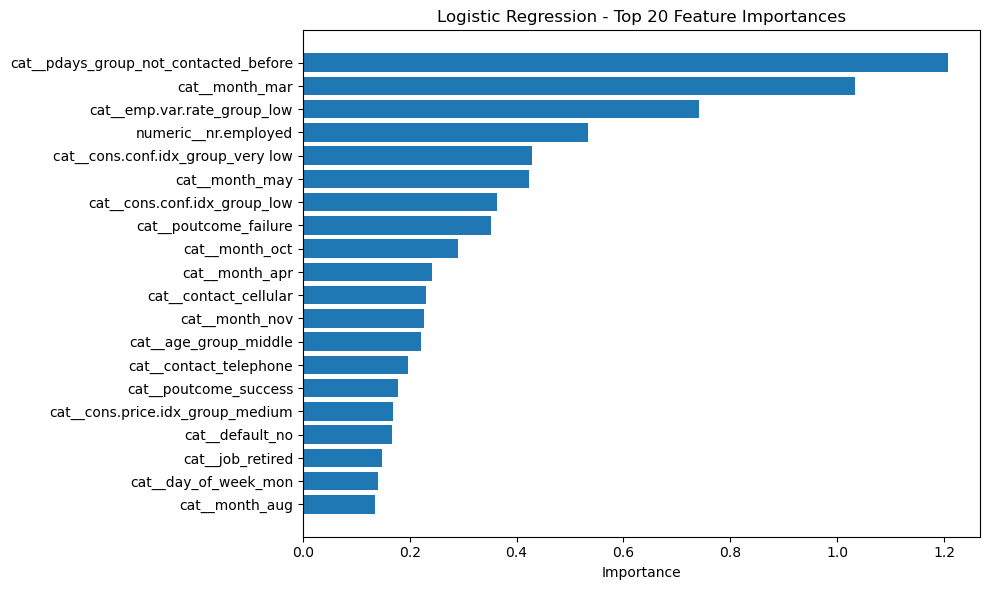

In [4]:
from src.visualizations import plot_feature_importance

plot_feature_importance(pipeline_rforest, top_n=20, name="Random Forest")
plot_feature_importance(pipeline_xgb, top_n=20, name="XGB")
plot_feature_importance(pipeline_logreg, top_n=20, name="Logistic Regression")

### Feature Importance Analysis

<span style="background-color: #4FC3F7; display:block; padding:10px">

The feature importance results across XGBoost, Random Forest, and Logistic Regression show several consistent patterns.

**Key Predictive Drivers**  
- Macroeconomic indicators such as `nr.employed`, `emp.var.rate`, and `cons.conf.idx` are among the most influential features, highlighting the strong impact of broader economic conditions.

**Customer History and Campaign Effects**  
- Features like `pdays`, `poutcome_success`, `poutcome_failure`, and `campaign` are consistently important, indicating that prior interactions and campaign outcomes are key predictors.

**Temporal Patterns**  
- Month-related features (e.g., `month_mar`, `month_may`, `month_oct`) appear across models, suggesting seasonal effects in campaign performance.

**Contact and Demographic Features**  
- Contact type and customer attributes (e.g., job and default-related features) contribute to predictions, reflecting differences across customer segments.

**Model-Specific Observations**  
- Tree-based models capture non-linear relationships using both numerical and categorical features.  
- Logistic Regression relies more on engineered group features, reflecting linear relationships and clearer feature effects.

**Overall Insight**  
The most important signals across models come from macroeconomic context, prior campaign interactions, and temporal features, indicating that customer behavior is driven by a combination of economic conditions, engagement history, and timing rather than a single dominant factor.

</span>

### Comparison with <a href="https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/01_eda.ipynb">EDA Hypotheses</a>

<span style="background-color: #4FC3F7; display:block; padding:10px">

The feature importance analysis largely confirms the hypotheses formulated during EDA, while also refining their relative importance.

**Client demographics**  
Demographic features such as age groups, job types, and default status appear in the models, but with moderate importance. This suggests they are relevant, but not the primary drivers of predictions.

**Socio-economic profile**  
Job-related features are present among important predictors, partially confirming their expected influence, though their impact is secondary compared to other feature groups.

**Financial status**  
The importance of default-related features aligns with EDA assumptions, while loan-related variables remain less influential.

**Marketing interaction history**  
Features related to previous contacts (`pdays`, `poutcome_*`) are among the most important across all models, strongly confirming that prior campaign interactions are key predictors.

**Temporal effects**  
Month-related features consistently appear among important variables, supporting the presence of seasonal patterns, while weekday effects are less pronounced than expected.

**Overall**  
The results validate the main EDA hypothesis that campaign outcomes depend on client characteristics, prior interactions, and temporal factors, while additionally highlighting the strong influence of macroeconomic indicators, which were not emphasized in the initial analysis.

</span>

## SHAP Analysis
### Data Preparation

- A single random subset of indices is sampled from the validation dataset to ensure all models are evaluated on the same observations.  
- The corresponding subset is extracted from `X_val` and `y_val` for aligned evaluation.  
- For each pipeline, the trained model is separated from preprocessing steps.  
- The subset is transformed into model-ready feature space for each pipeline and converted into DataFrames with feature names.  
- Predictions are generated for each model on the same validation subset to enable comparison.
- SHAP values are computed for each model using the corresponding transformed feature subset to explain individual predictions.

As a result, we obtain:
- trained models from each pipeline  
- a shared validation subset  
- model-specific transformed feature representations for SHAP  
- aligned predictions for consistent comparison across models  
- SHAP values for each model, enabling consistent interpretation and comparison of feature contributions across models  

In [5]:
from src.analysis.utils import get_model_and_subset, log_odds_to_proba

In [6]:
# generate indeces for forming subset
subset_indices = np.random.default_rng(4242).choice(
    X_val.index, size=200, replace=False
)

# extract models from pipelines, create pipeline specific subsets for visualizations
model_xgb, X_subset_xgb, X_full_xgb, _ = get_model_and_subset(pipeline_xgb, X_val, subset_indices=subset_indices)
model_rf, X_subset_rf, X_full_rf, _ = get_model_and_subset(pipeline_rforest, X_val, subset_indices=subset_indices)
model_lr, X_subset_lr, X_full_lr, _ = get_model_and_subset(pipeline_logreg, X_val, subset_indices=subset_indices)

# create validation data subset for analysis and comparison
X_val_subset = X_val.loc[subset_indices]
y_val_subset = y_val.loc[subset_indices]

# prediction per each pipeline for validation data subset
y_val_subset_pred_xgb = pipeline_xgb.predict(X_val_subset)
y_val_subset_pred_rf = pipeline_rforest.predict(X_val_subset)
y_val_subset_pred_lr = pipeline_logreg.predict(X_val_subset)

# xgb prediction to "yes"/"no" format for consistency
y_val_subset_pred_xgb = np.where(y_val_subset_pred_xgb == 1, "yes", "no")

In [7]:
# print accuracy to check if all good
print("XGB accuracy:", np.mean(y_val_subset_pred_xgb == y_val_subset))
print("RF accuracy:", np.mean(y_val_subset_pred_rf == y_val_subset))
print("Log Reg accuracy:", np.mean(y_val_subset_pred_lr == y_val_subset))

XGB accuracy: 0.86
RF accuracy: 0.85
Log Reg accuracy: 0.85


In [8]:
# random forest - SHAP values
explainer_rf = shap.TreeExplainer(model_rf)
shap_values_rf = explainer_rf(X_subset_rf, check_additivity=False)

In [9]:
# XGB - SHAP values
# Use predict_proba here instead of the raw model simply because could not avoid SHAP combine with XGB error related to some model-specific internal representations otherwise
# As result - SHAP values are computed in terms of class probabilities (might be even more interpretable than log-odds)
explainer_xgb = shap.Explainer(
    model_xgb.predict_proba,
    X_subset_xgb
)

shap_values_xgb = explainer_xgb(X_subset_xgb)

In [10]:
# Log Reg - SHAP values
explainer_lr = shap.LinearExplainer(model_lr, X_subset_lr)
shap_values_lr = explainer_lr(X_subset_lr)

### SHAP - Features importance  

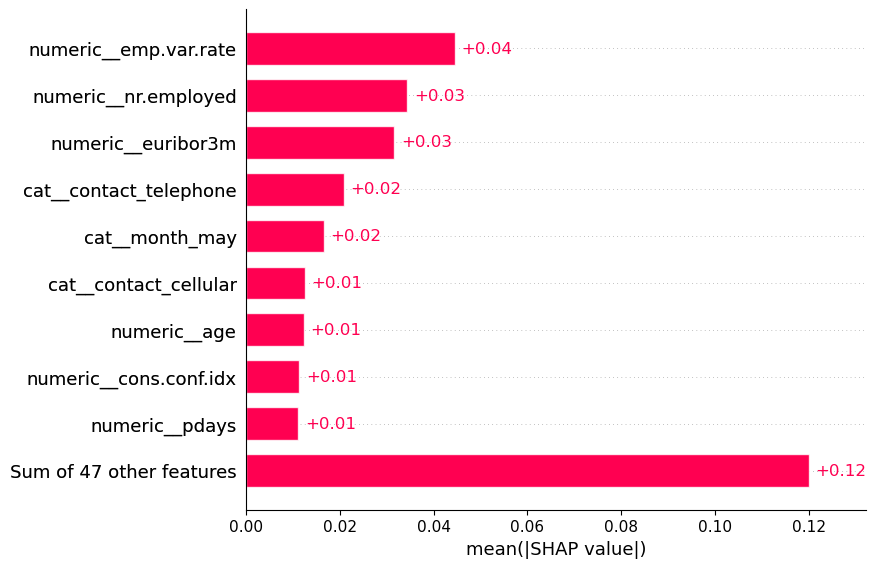

In [11]:
# Random Forest
shap.plots.bar(shap_values_rf[:, :, 1])

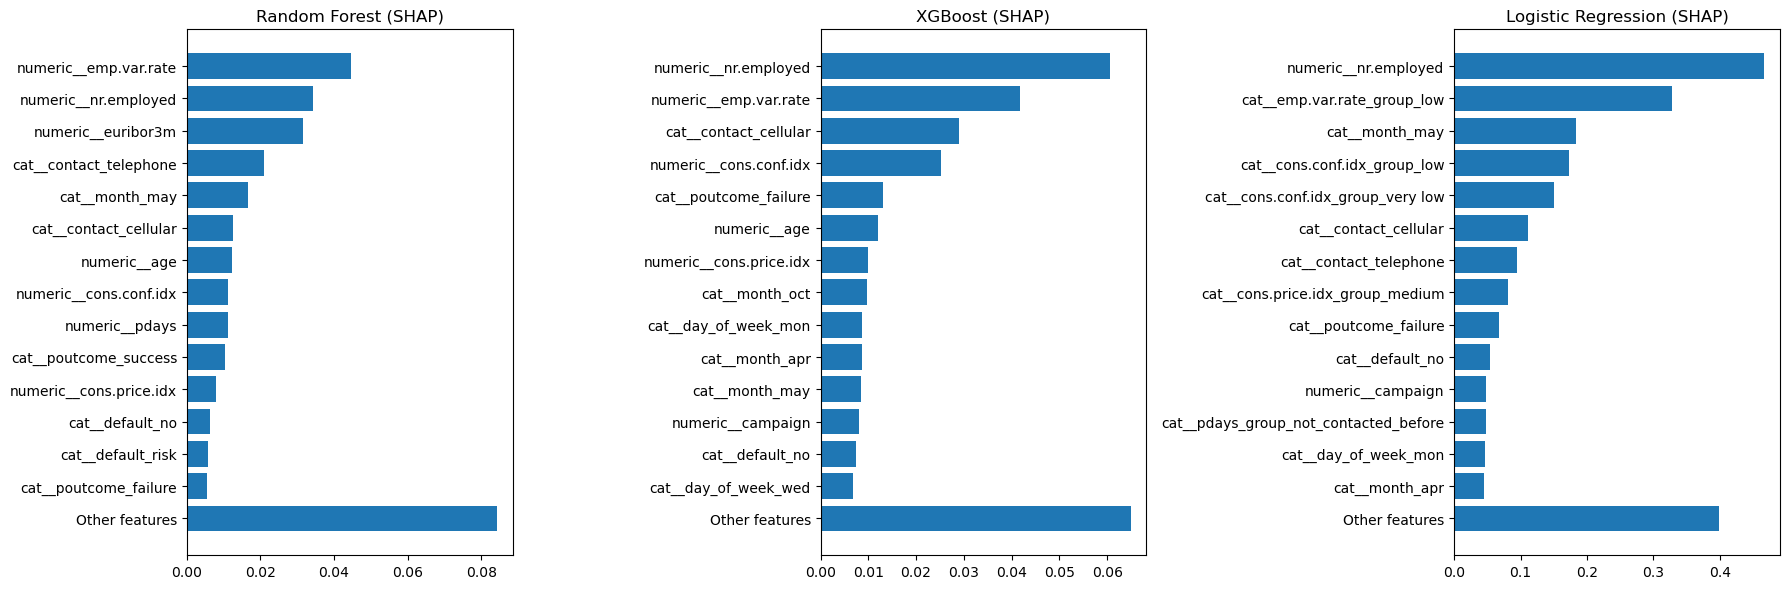

In [46]:
from src.analysis.utils import plot_shap_comparison

# compare 3 models
plot_shap_comparison(shap_values_rf, shap_values_xgb, shap_values_lr)

<span style="background-color: #4FC3F7; display:block; padding:10px">

 **SHAP - Features importance Conclusion**

 - SHAP analysis shows that the most influential features across all models are macro-economic indicators (nr.employed, emp.var.rate, cons.conf.idx, cons.price.idx) and campaign-related variables (pdays, poutcome, campaign, contact type).

 - Model-Specific Observations:
    - Random Forest and XGBoost place strong emphasis on raw economic indicators, while Logistic Regression relies more on engineered categorical features associated with the same economic indicators, as well as with age and temporal variables.
    - Random Forest more distributes importance across many features (incl. Other features) while XGBoost relies more on several most important features

 - These findings are consistent with the earlier feature importance analysis, confirming that economic conditions and prior customer interaction history are the primary drivers of the model predictions. SHAP further refines this insight by showing the directional contribution of each feature to individual predictions.

</span>

### SHAP - Summary Plot (beeswarm)

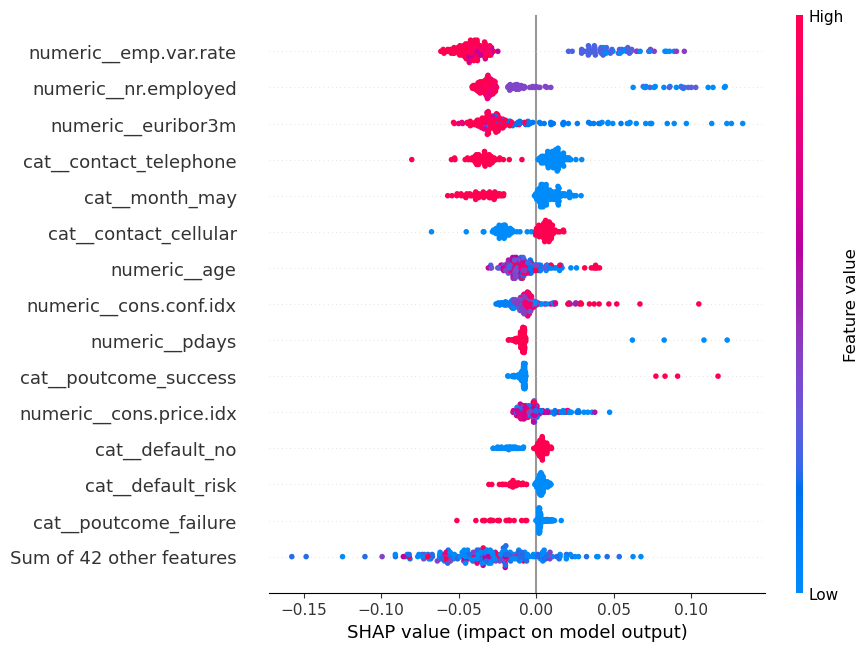

In [13]:
# Random Forest
shap.plots.beeswarm(shap_values_rf[:, :, 1], max_display=15)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Random Forest Summary (Conclusion)**

- In SHAP summary (beeswarm) plots, each point represents one observation, and features are ordered by overall importance (mean absolute SHAP value).

- The color of each point represents the feature value:
  - **Red** = high feature value  
  - **Blue** = low feature value  

- The horizontal position (SHAP value) shows the impact on the model output:
  - Points to the **right (positive SHAP)** increase the probability of the target class ("yes")  
  - Points to the **left (negative SHAP)** decrease the probability of the target class  

- Economic indicators (`emp.var.rate`, `nr.employed`, `euribor3m`) are the most influential features. In general, higher values tend to be associated with negative SHAP values, reducing the probability of subscription, although some non-linear effects might be present.

- The contact method is a strong behavioral driver: cellular contact increases the likelihood of a positive outcome, while telephone contact reduces it.

- Previous campaign outcomes (`poutcome_success`, `poutcome_failure`) and contact history (`pdays`) are highly impactful, with success strongly increasing and failure decreasing the probability of subscription.

- Credit-related features (`default_no`, `default_risk`) also contribute meaningfully, where risk status negatively affects predictions.

- Demographic features such `numeric__age` have weaker and more variable effects, indicating limited standalone influence compared to economic and behavioral factors.

- Among Temporal features only `cat__month_may` is among top influential features and has negativive affect on target class "yes"

- The feature `numeric__cons.conf.idx` shows a non-linear, context-dependent influence, suggesting interactions with other variables rather than a consistent directional effect.

</span>

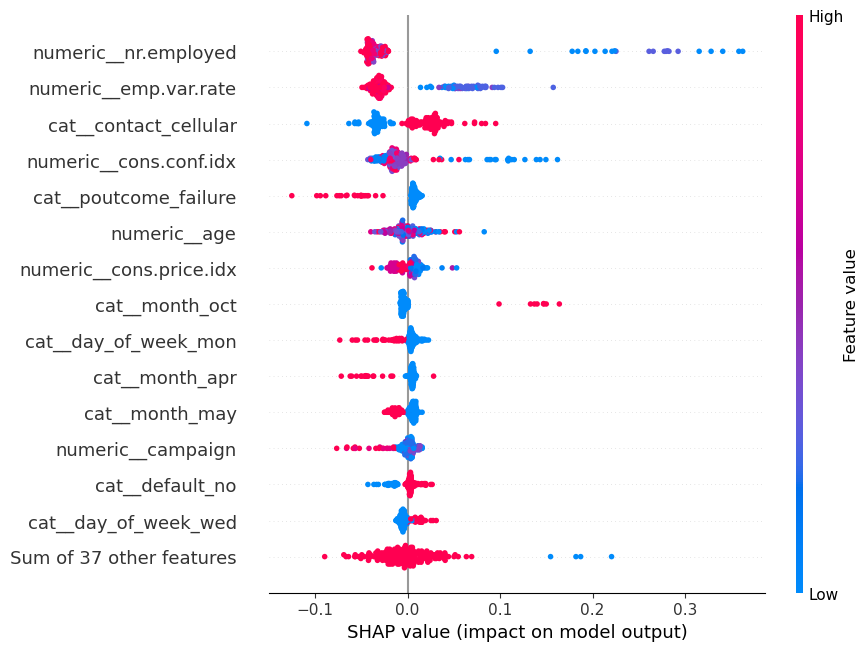

In [14]:
# XGB
shap.plots.beeswarm(shap_values_xgb[:, :, 1], max_display=15)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – XGB Summary (Conclusion)**

- Economic indicators (`emp.var.rate`, `nr.employed`) show similar directional effects as in the Random Forest model. However, `nr.employed` has a stronger impact in XGBoost, suggesting that this model relies more on employment-related signals.

- The contact method remains important: `cat__contact_cellular` has a stronger positive impact compared to Random Forest, suggesting XGB places more emphasis on communication channel effectiveness.

- Monthly features are more diversified in XGB. While `cat__month_may` still appears, additional months such as `cat__month_oct` and `cat__month_apr` are among the top features:
  - `cat__month_oct`: red values push predictions strongly to the right (positive impact)
  - `cat__month_apr`: red values push predictions to the left (negative impact)  
  This indicates XGB captures more granular temporal patterns than Random Forest.

- The feature `numeric__campaign` shows that higher values (red points) tend to decrease the probability of subscription, while lower values (blue) are closer to neutral, indicating diminishing returns with repeated contacts.

- Additional categorical features such as `cat__day_of_week_wed` and `cat__day_of_week_mon` appear among the most important features in XGB, whereas they were not prominent in the Random Forest model. This suggests XGB captures additional interaction effects related to timing.

- Features like `poutcome_failure` and `default_no` remain consistently influential across both models, confirming their robustness as predictors.

- Compared to Random Forest, XGB shows a broader spread of impactful features: several non-top features collectively contribute meaningfully, indicating that the model distributes importance more across variables rather than concentrating it in a smaller subset.

- Overall, XGB captures more nuanced and diverse patterns (especially temporal and interaction effects), while Random Forest relies more heavily on a smaller set of dominant economic and behavioral features.
</span>

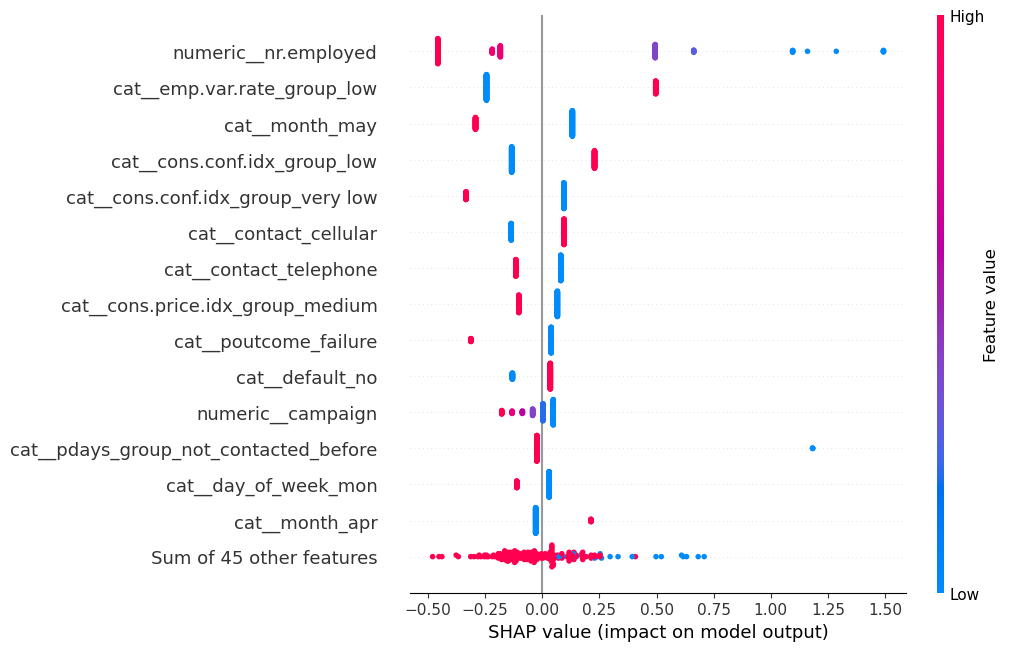

In [15]:
# Log Reg
shap.plots.beeswarm(shap_values_lr, max_display=15)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Logistic Regression Summary (Observation)**

- Most of the top features in the logistic regression model are categorical (`cat__`), which is expected due to one-hot encoding.

- In the SHAP beeswarm plot, these categorical features typically form two distinct vertical bands:
  - One group of points at **0 (blue)** representing the absence of the category  
  - One group at **1 (red)** representing the presence of the category  

- The horizontal spread of these two groups reflects the model’s learned coefficient:
  - If the red points are far to the **right**, the category strongly increases the probability of the target class ("yes")  
  - If the red points are far to the **left**, the category strongly decreases the probability  

- The distance from zero indicates the strength of the feature’s impact:
  - Features with points farther from zero have **larger absolute coefficients** and therefore stronger influence on predictions  
  - Features clustered close to zero have weaker influence  

- Compared to tree-based models (Random Forest and XGBoost), logistic regression produces more **linear and symmetric patterns**, where each feature contributes additively and independently, resulting in clearer separation between positive and negative contributions.

</span>

### SHAP - Dependence plots (scatter)

#### Tree based models

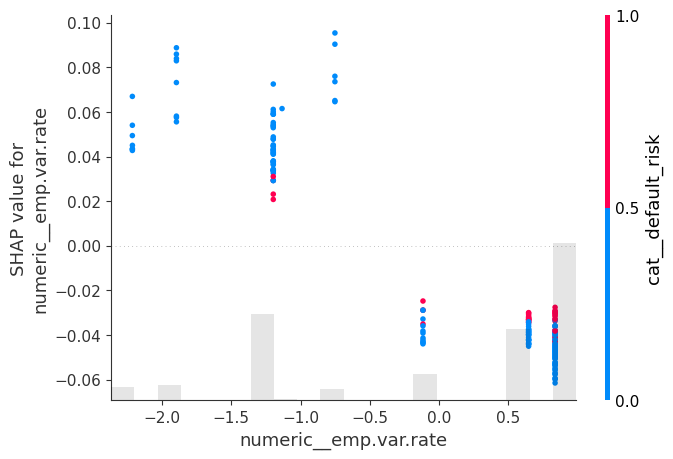

In [16]:
shap.plots.scatter(
    shap_values_rf[:, "numeric__emp.var.rate", 1],
    color=shap_values_rf[:, :, 1]
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Random Forest Dependence Plot (Conclusion)**

The SHAP scatter plot for `numeric__emp.var.rate` shows a clear negative relationship with the model output: lower values contribute positively to the probability of subscription, while higher values reduce it. Additionally, coloring by `cat__default_risk` reveals an interaction effect, where higher default risk is associated with more negative SHAP values at higher employment variation rates. This suggests that unfavorable economic conditions combined with higher credit risk reinforce the model’s tendency to predict a lower likelihood of subscription.

</span>

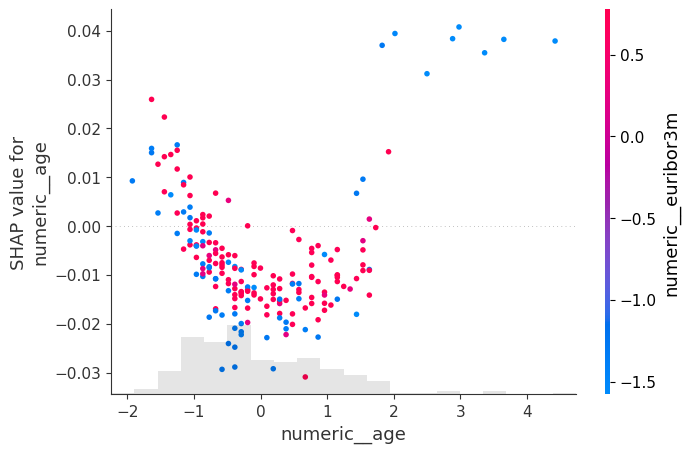

In [17]:
shap.plots.scatter(
    shap_values_rf[:, "numeric__age", 1],
    color=shap_values_rf[:, :, 1]
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Random Forest Dependence Plot (Conclusion)**

The SHAP scatter plot for `numeric__age` shows a non-linear relationship with the model output. Very low and very high age values tend to have a positive impact on the probability of subscription, while medium age values generally have a slightly negative impact. This suggests a U-shaped effect of age on predictions.

When coloring by `numeric__euribor3m`, no strong interaction pattern is observed, indicating that interest rates do not significantly modify the effect of age. The feature `age` therefore appears to act mostly independently, with limited interaction effects and a relatively weaker overall influence compared to more dominant economic and behavioral features.

</span>

#### Logistic Regression

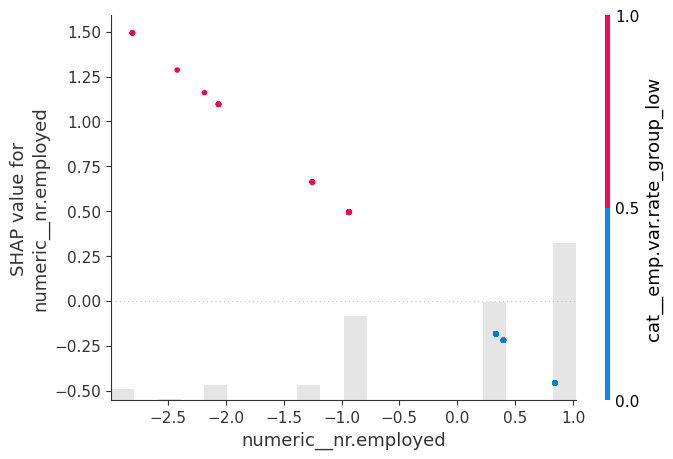

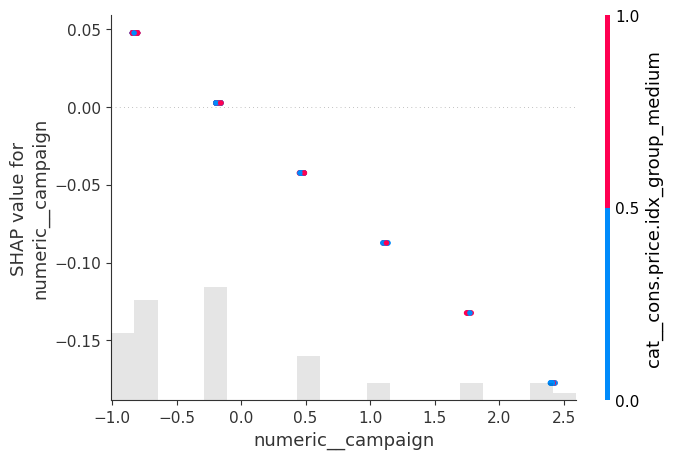

In [18]:
# two most important among numeric features of logisting regression
shap.plots.scatter(
    shap_values_lr[:, "numeric__nr.employed"],
    color=shap_values_lr[:, "cat__emp.var.rate_group_low"]
)

shap.plots.scatter(
    shap_values_lr[:, "numeric__campaign"],
    color=shap_values_lr[:, :]
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Logistic Regression Dependence Plots (Conclusion)**

The scatter plots for logistic regression show a clear linear relationship between feature values and their SHAP contributions. For `numeric__nr.employed`, higher values consistently lead to negative SHAP values, while lower values contribute positively. Coloring by `cat__emp.var.rate_group_low` reveals a strong alignment between the two features, suggesting correlation rather than interaction.

For `numeric__campaign`, a similar linear negative relationship is observed, where higher values reduce the probability of subscription. When colored by `cat__cons.price.idx_group_medium`, no strong separation is visible, indicating weak or no interaction between these features. Overall, the patterns reflect the linear nature of logistic regression, where features contribute additively and interactions are limited.

</span>

### SHAP - Heatmap

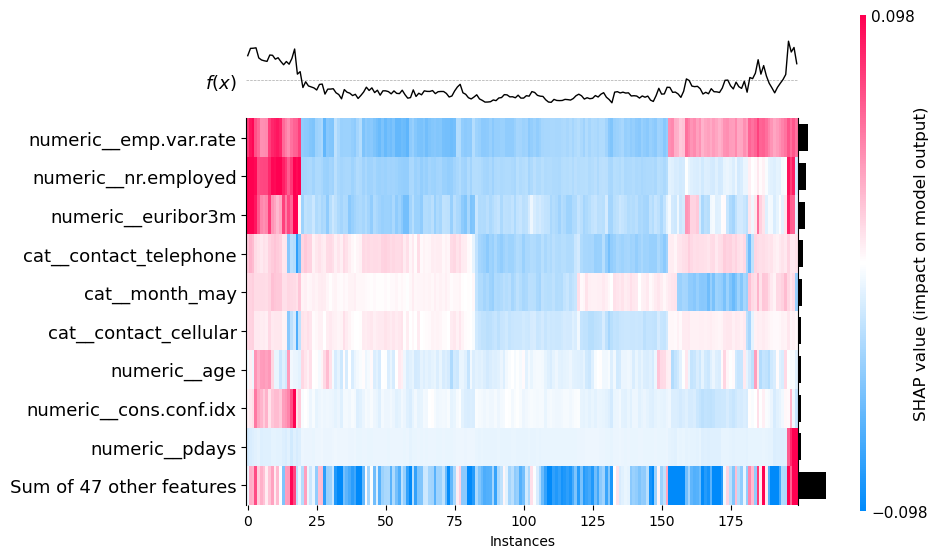

In [19]:
shap.plots.heatmap(shap_values_rf[:, :, 1]);

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Random Forest Heatmap (Conclusion)**

The SHAP heatmap shows that a few key features—mainly economic indicators—drive most of the model’s predictions. Their effects vary across samples, with both positive and negative contributions, suggesting non-linear relationships and interactions. Clear patterns across observations indicate the model captures distinct behavior groups. Although lower-ranked features have smaller individual effects, together they still contribute meaningfully

</span>

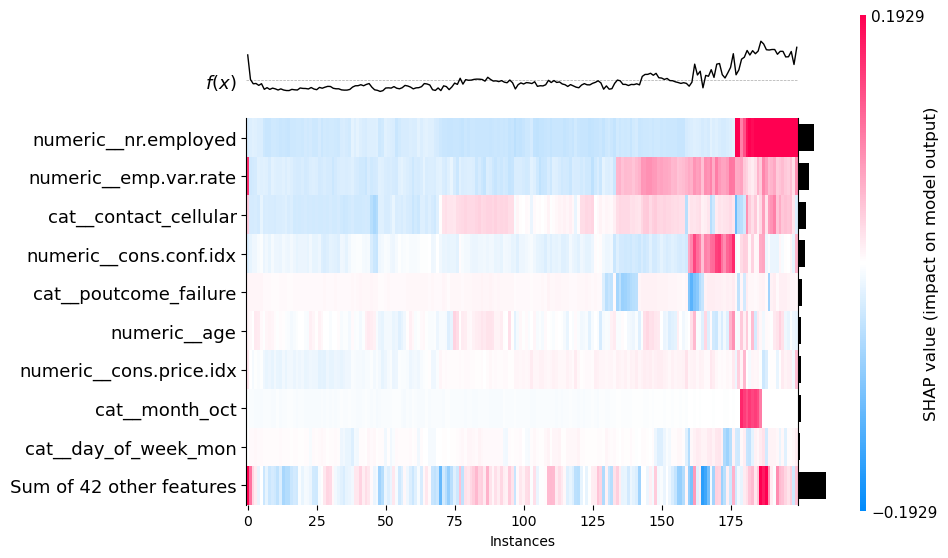

In [20]:
shap.plots.heatmap(shap_values_xgb[:, :, 1]);

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – XGB Heatmap (Conclusion)**

A few economic indicators—especially `nr.employed` and `emp.var.rate`  dominate the predictions. Their effects are more structured, with smoother and more consistent patterns across values, while most other features have weak contributions with only occasional strong impacts.

Comparison with Random Forest:
Compared to Random Forest, XGBoost shows more concentrated and stable feature effects, with fewer widespread strong SHAP values and less influence from secondary features.

</span>

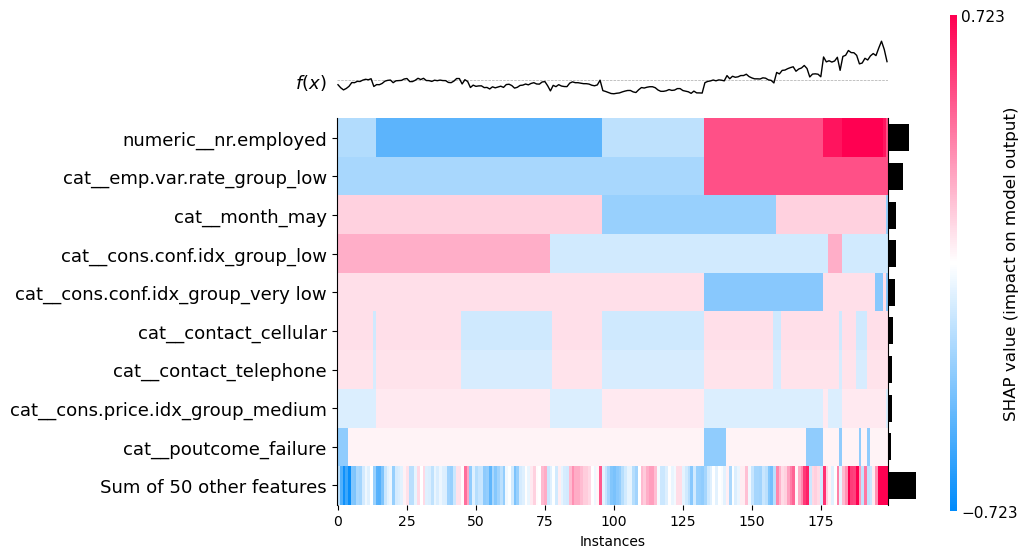

In [21]:
shap.plots.heatmap(shap_values_lr[:, :]);

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Lgistic Regression Heatmap (Conclusion)**

A few key features (e.g., nr.employed, emp.var.rate_group_low, cons.conf.idx groups, month_may) show clear directional effects, while most other features have weaker, more uniform influence.

The SHAP heatmap for logistic regression shows that the top features have a clear directional effect. The remaining features are more evenly distributed, indicating weaker and more uniform influence. Overall, the model is driven mainly by a few dominant linear features.

</span>

### SHAP Force Plots: Analysis by Confusion Matrix

This section covers data preparation by splitting predictions into TP, TN, FP, and FN, followed by an analysis of selected correctly predicted samples.

Examples of incorrect predictions are discussed in the **Error Analysis** section below.

In [23]:
from src.analysis.utils import get_shap_per_confusion_matrix, get_common_indexes, get_single_explanation

shap_cm_rf = get_shap_per_confusion_matrix(y_val_subset, y_val_subset_pred_rf, X_subset_rf, shap_values_rf)
shap_cm_xgb = get_shap_per_confusion_matrix(y_val_subset, y_val_subset_pred_xgb, X_subset_xgb, shap_values_xgb)
shap_cm_lr = get_shap_per_confusion_matrix(y_val_subset, y_val_subset_pred_lr, X_subset_lr, shap_values_lr)

In [24]:
preds = {
    "rf": y_val_subset_pred_rf,
    "xgb": y_val_subset_pred_xgb,
    "lr": y_val_subset_pred_lr,
}

# work only with correct predictions here
common_tp = get_common_indexes(y_val_subset, preds, "yes", "yes")
common_tn = get_common_indexes(y_val_subset, preds, "no", "no")

#### True Positive

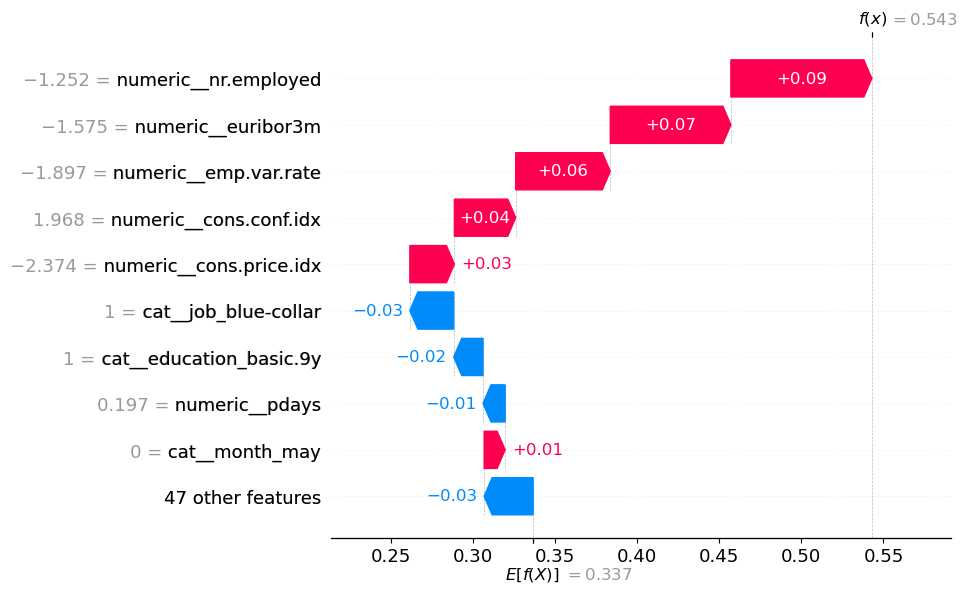

In [25]:
# pick one example
tp_idx = common_tp[0]

# map to positions
tp_pos_rf = list(X_subset_rf.index).index(tp_idx)
tp_pos_xgb = list(X_subset_xgb.index).index(tp_idx)
tp_pos_lr = list(X_subset_lr.index).index(tp_idx)

# plot, describe and analyse only for random forest first
shap.plots.waterfall(get_single_explanation(shap_values_rf, tp_pos_rf))

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP Waterfall Interpretation — True Positive (Random Forest)**

- Prediction Overview
    - Baseline: `E[f(x)] = 0.337`
    - Final prediction: `f(x) = 0.543`
    - Shift: `+0.206` toward **"yes"**
    - Interpretation:
        - Model starts from average prediction
        - Feature contributions move it toward the final output

---

- How to Read SHAP Values
    - Positive SHAP → pushes toward `"yes"`
    - Negative SHAP → pushes toward `"no"`

---

- Positive Contributors (toward "yes")
    - `nr.employed` → `+0.09`
    - `euribor3m` → `+0.07`
    - `emp.var.rate` → `+0.06`
    - `cons.conf.idx` → `+0.04`
    - `cons.price.idx` → `+0.03`
    - Interpretation:
        - Macro-economic features dominate
        - They drive the prediction toward "yes"

---

- Negative Contributors (toward "no")
    - `job_blue-collar` → `-0.03`
    - `education_basic.9y` → `-0.02`
    - `pdays` → `-0.01`
    - Other features → `-0.03`
    - Interpretation:
        - Individual features slightly oppose the prediction
        - Their impact is weak

---

- Model Decision Logic
    - Multiple moderate positive signals outweigh weak negatives
    - Prediction results from combined feature effects
    - No single feature dominates

---

- Key Pattern
    - Strong drivers: macro-economic variables
    - Weaker influence: demographic / individual attributes
    - Random Forest distributes importance across many features

---

- Conclusion
    - Correct prediction (True Positive)
    - Driven by several aligned macro-level signals
    - Model captures broad patterns rather than relying on a single feature

</span>

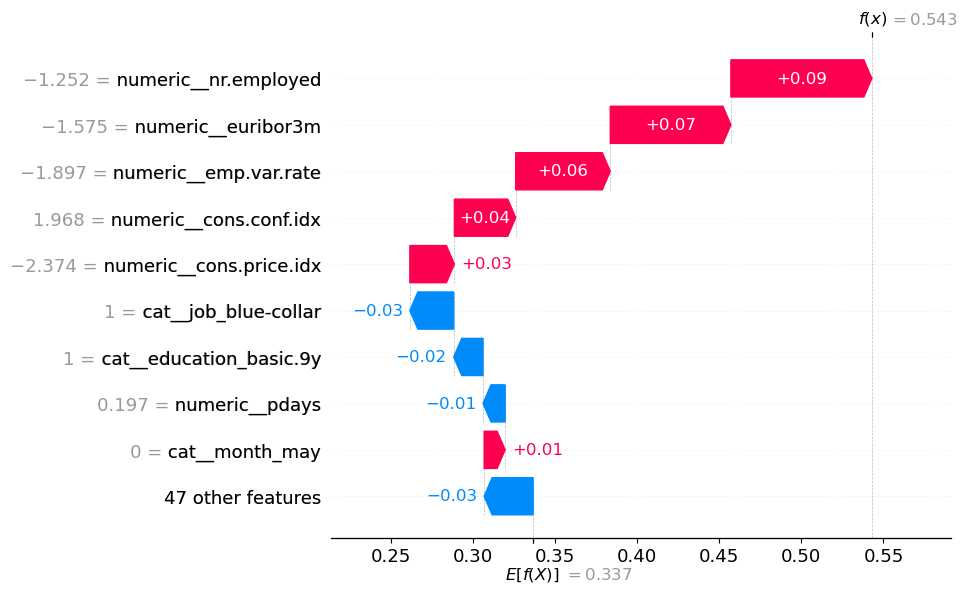

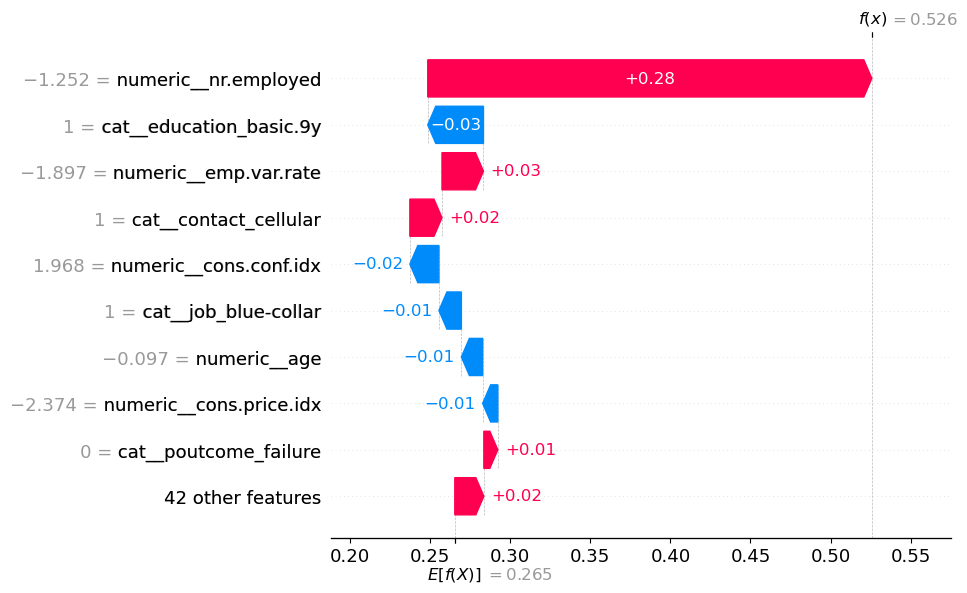

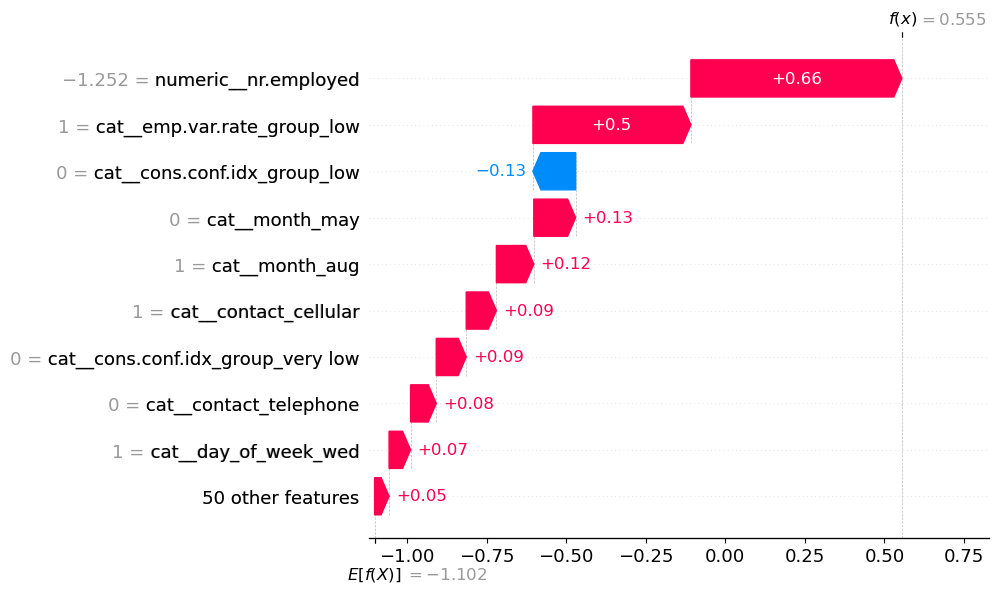

In [26]:
# plot waterfall side-by-side
shap.plots.waterfall(get_single_explanation(shap_values_rf, tp_pos_rf))
shap.plots.waterfall(get_single_explanation(shap_values_xgb, tp_pos_xgb))
shap.plots.waterfall(get_single_explanation(shap_values_lr, tp_pos_lr))

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP Comparison — Same True Positive Across 3 Models (RF vs XGB vs LR)**

- Prediction Alignment
    - All three models predict "yes"
    - Decision is reached through different reasoning patterns

---

- Overall Signal Strength
    - RF: moderate shift via many features  
    - XGB: moderate shift dominated by a single strong feature
    - LR: larger shift from a more negative baseline via additive effects  
    - Note: Differences are influenced by model output scales

---

- Dominant Feature (`nr.employed`)
    - Important across all models
    - Ranks among the top contributors in each model
    - Note: SHAP magnitudes are not directly comparable across models, but relative importance within each model is consistent

---

- Feature Usage Patterns
    - RF: distributed small-to-medium contributions  
    - XGB: One feature dominates, others provide small adjustments
    - LR: additive combination of many encoded features  

---

- Agreement vs Divergence
    - Agreement: all models identify `nr.employed` and macro-economic signals as important  
    - Divergence: RF spreads importance, XGB concentrates it, LR distributes it linearly  

---

- Key Insight
    - Same prediction, different reasoning:
        - RF → distributed evidence  
        - XGB → dominant feature + interactions
        - LR → linear accumulation of features  
    - Differences in contribution magnitude are influenced by model structure, not only by true differences in feature importance across models.

---

- Conclusion
    - Prediction is robust across models  
    - All models agree on key drivers, especially `nr.employed`  
    - Explanations differ due to model design rather than conflicting signals  

</span>

#### True Negative

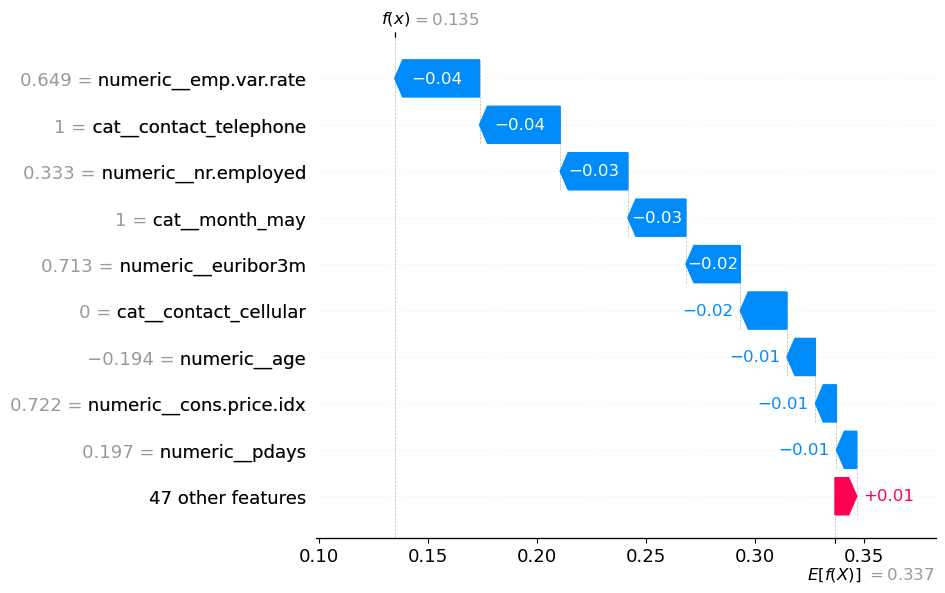

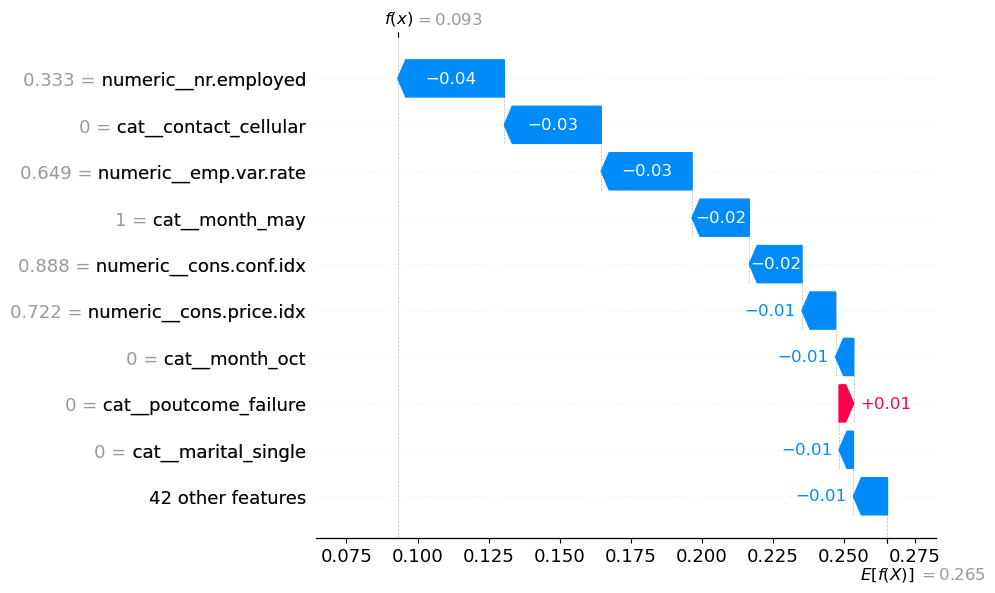

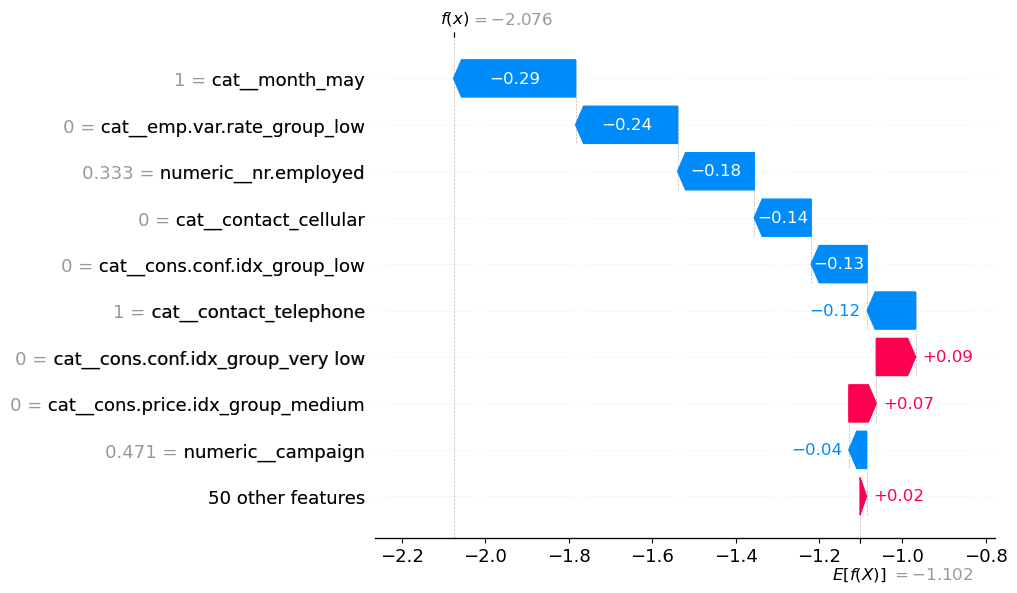

In [27]:
# same for TN
tn_idx = common_tn[0]

tn_pos_rf = list(X_subset_rf.index).index(tn_idx)
tn_pos_xgb = list(X_subset_xgb.index).index(tn_idx)
tn_pos_lr = list(X_subset_lr.index).index(tn_idx)

shap.plots.waterfall(get_single_explanation(shap_values_rf, tn_pos_rf))
shap.plots.waterfall(get_single_explanation(shap_values_xgb, tn_pos_xgb))
shap.plots.waterfall(get_single_explanation(shap_values_lr, tn_pos_lr))

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP Comparison — Same True Negative Across 3 Models (RF vs XGB vs LR)**

- Prediction Alignment
    - All three models predict "no"
    - The decision is achieved through different feature contribution patterns

---

- Overall Signal Strength
    - RF: reduced via several small negative contributions  
    - XGB: similar reduction with comparable small-to-moderate negative contributions  
    - LR: larger negative shift from a different baseline via additive effects  
    - Note: Differences in magnitude are influenced by model output scales and are not directly comparable across models

---

- Dominant Features
    - `nr.employed` and `emp.var.rate` are consistently important across all models
    - RF/XGB: small-to-moderate negative contributors in this example  
    - LR: stronger negative contributions within its scale  
    - Insight: These macro-economic features consistently push predictions toward "no" and rank highly in each model

---

- Feature Usage Patterns
    - RF: many small contributions, distributed influence  
    - XGB: similar pattern with slightly more noticeable contributions in some features  
    - LR: linear combination of multiple encoded features  

---

- Agreement vs Divergence
    - Agreement: all models rely on macro-economic variables as key drivers  
    - Divergence: RF and XGB both distribute importance across multiple features, while LR distributes it through a linear combination of encoded inputs  

---

- Key Insight
    - Same prediction, similar reasoning across RF and XGB, with LR following a different (linear) mechanism:
        - RF → distributed weak signals  
        - XGB → comparable small-to-moderate contributions  
        - LR → additive linear effects  
    - Differences in contribution size reflect model structure and scaling, not direct cross-model importance  

---

- Conclusion
    - The true negative prediction is robust across models  
    - All models agree on key drivers, especially macro-economic features  
    - In this case, RF and XGB show broadly similar contribution patterns, while LR differs due to its linear formulation  
    - Explanations differ due to model design rather than conflicting signals  

</span>

## Error Analysis

### Confusion matrix

#### Validation Data Subset

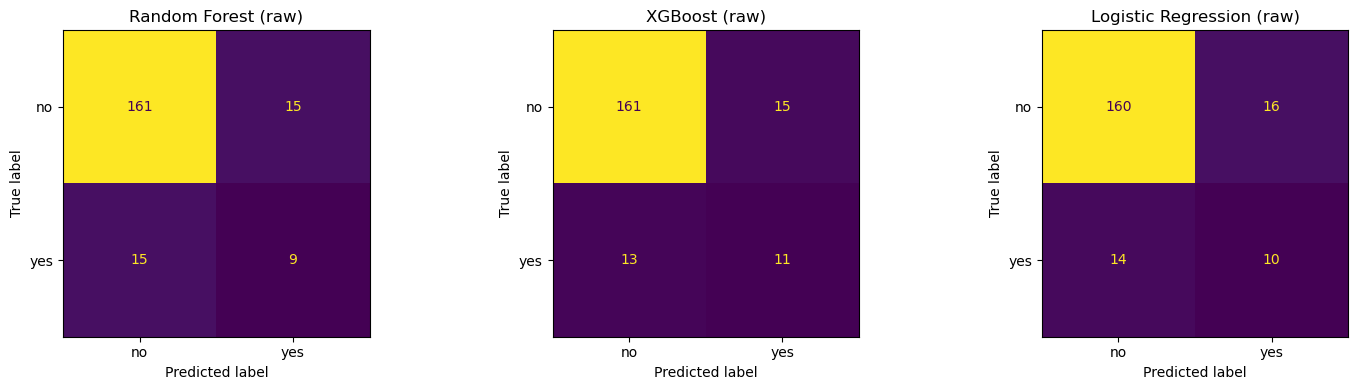

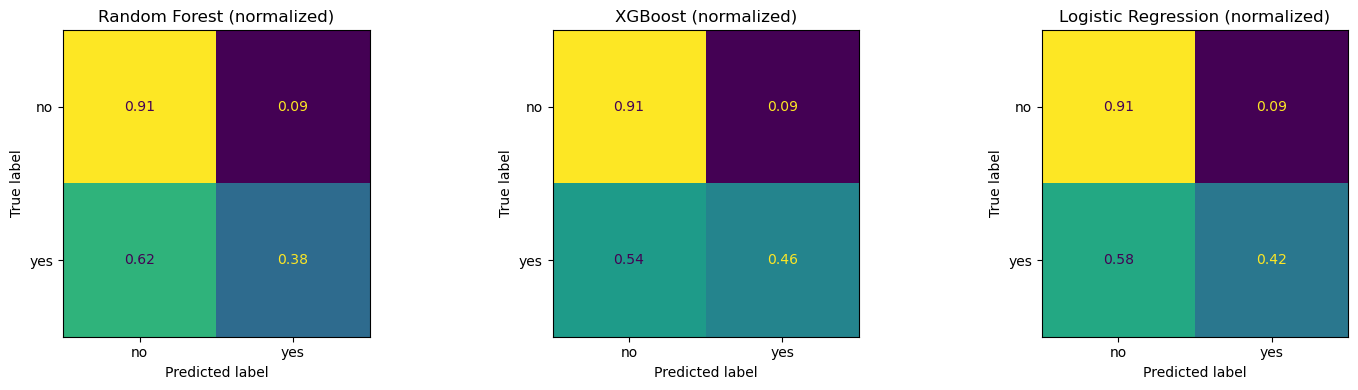

In [28]:
from src.analysis.utils import plot_confusion_matrices

subset_preds = {
    "Random Forest": y_val_subset_pred_rf,
    "XGBoost": y_val_subset_pred_xgb,
    "Logistic Regression": y_val_subset_pred_lr
}

# Raw counts
plot_confusion_matrices(y_val_subset, subset_preds, normalize=None)

# Normalized (row-wise)
plot_confusion_matrices(y_val_subset, subset_preds, normalize='true')

#### Full Validation Data

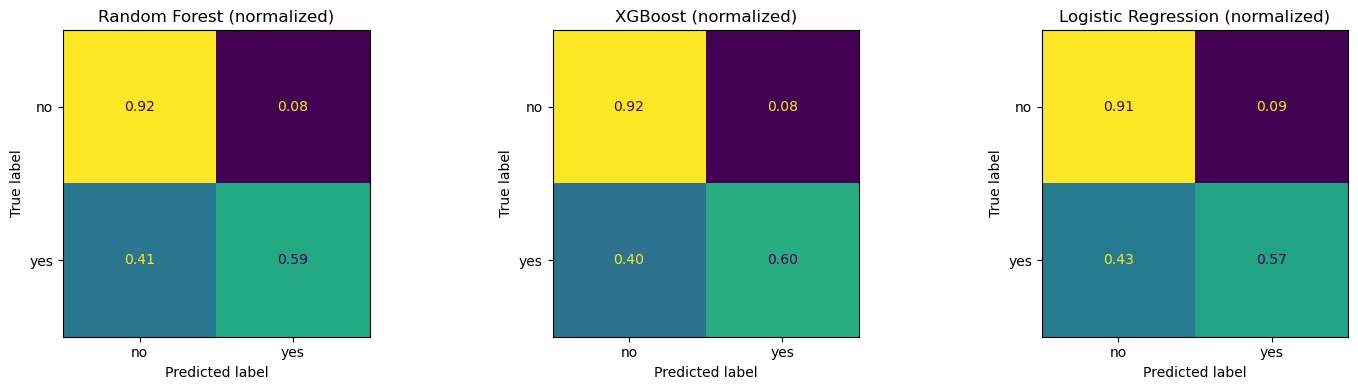

In [29]:
y_val_pred_xgb = pipeline_xgb.predict(X_val)
y_val_pred_rf = pipeline_rforest.predict(X_val)
y_val_pred_lr = pipeline_logreg.predict(X_val)

y_val_pred_xgb = np.where(y_val_pred_xgb == 1, "yes", "no")

full_preds = {
    "Random Forest": y_val_pred_rf,
    "XGBoost": y_val_pred_xgb,
    "Logistic Regression": y_val_pred_lr,
}

# Normalized (row-wise)
plot_confusion_matrices(y_val, full_preds, normalize='true')

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Confusion Matrix Analysis — Model Comparison**

- Overall
    - All models perform similarly
    - Strong performance on class "no"
    - Differences mainly appear on class "yes"

---

- Class "no" (True Negatives)
    - Subset: ~91–92% for all models  
    - Full data: ~91–92% for all models  
    - Insight: All models consistently identify "no" with high accuracy

---

- Class "yes" (Recall / True Positives)
    - Subset:
        - RF: 37.5%
        - XGB: 45.8%
        - LR: 41.7%
    - Full data:
        - RF: 58.9%
        - XGB: 60.1%
        - LR: 56.9%
    - Insight: XGBoost performs best at detecting "yes"

---

- Key Insight
    - Models are biased toward the majority class ("no")
    - XGBoost provides the best balance, especially for the minority class
    - Random Forest and Logistic Regression perform slightly worse on recall

---

- Metric Consideration
    - During modeling, F1-score was used as the main evaluation metric
    - However, given the relatively low recall for class "yes":
        - In a real-world business setting, it would likely be more important to prioritize Recall for the "yes" class
        - This would reduce the number of missed positive cases (false negatives)
    - For learning and comparative modeling purposes, the current results are still satisfactory

---

- Conclusion
    - All models are robust and comparable overall
    - XGBoost is slightly better at capturing positive cases
    - Differences are modest but consistent across datasets
    - Future improvements could focus on increasing recall for the "yes" class depending on business priorities

</span>

### SHAP Force Plots - FP and FN Analysis

Data was prepared in **SHAP Force Plots: Analysis by Confusion Matrix** section above.

This section focuses on incorrectly predicted samples:
- False Positives (FP): predicted "yes", actual "no"
- False Negatives (FN): predicted "no", actual "yes"

In [ ]:
preds_dict = {
    "rf": y_val_subset_pred_rf,
    "xgb": y_val_subset_pred_xgb,
    "lr": y_val_subset_pred_lr
}

# create preds data frame and add true values there
preds_df = pd.DataFrame(preds_dict, index=X_subset_rf.index)
preds_df["y_true"] = y_val_subset.loc[X_subset_rf.index]

# work only with incorrect predictions here
common_fn = get_common_indexes(y_val_subset, preds_dict, "yes", "no")
common_fp = get_common_indexes(y_val_subset, preds_dict, "no", "yes")

In [31]:
# helper re-usable function
def plot_shap_waterfall_for_idx(idx):
    print(f"\n--- Example index: {idx} ---")
    print(val_df.loc[idx])

    # map to positions in each model subset
    pos_rf = list(X_subset_rf.index).index(idx)
    pos_xgb = list(X_subset_xgb.index).index(idx)
    pos_lr = list(X_subset_lr.index).index(idx)

    print(f"\nRandom Forest, predicted - {preds_df.loc[idx]['rf']}")
    shap.plots.waterfall(get_single_explanation(shap_values_rf, pos_rf))
    # print(get_single_explanation(shap_values_rf, pos_rf))

    print(f"\nXGBoost, predicted - {preds_df.loc[idx]['xgb']}")
    shap.plots.waterfall(get_single_explanation(shap_values_xgb, pos_xgb))
    # print(get_single_explanation(shap_values_xgb, pos_xgb))

    print(f"\nLogistic Regression, predicted - {preds_df.loc[idx]['lr']}")
    shap.plots.waterfall(get_single_explanation(shap_values_lr, pos_lr))
    # print(get_single_explanation(shap_values_lr, pos_lr))

#### False Negatives (FN)


--- Example index: 25314 ---
age                        50
job                 housemaid
marital               married
education            basic.4y
default                    no
housing                   yes
loan                       no
contact             telephone
month                     nov
day_of_week               tue
duration                  150
campaign                    2
pdays                     999
previous                    0
poutcome          nonexistent
emp.var.rate             -0.1
cons.price.idx           93.2
cons.conf.idx           -42.0
euribor3m               4.153
nr.employed            5195.8
y                         yes
Name: 25314, dtype: object

Random Forest, predicted - no


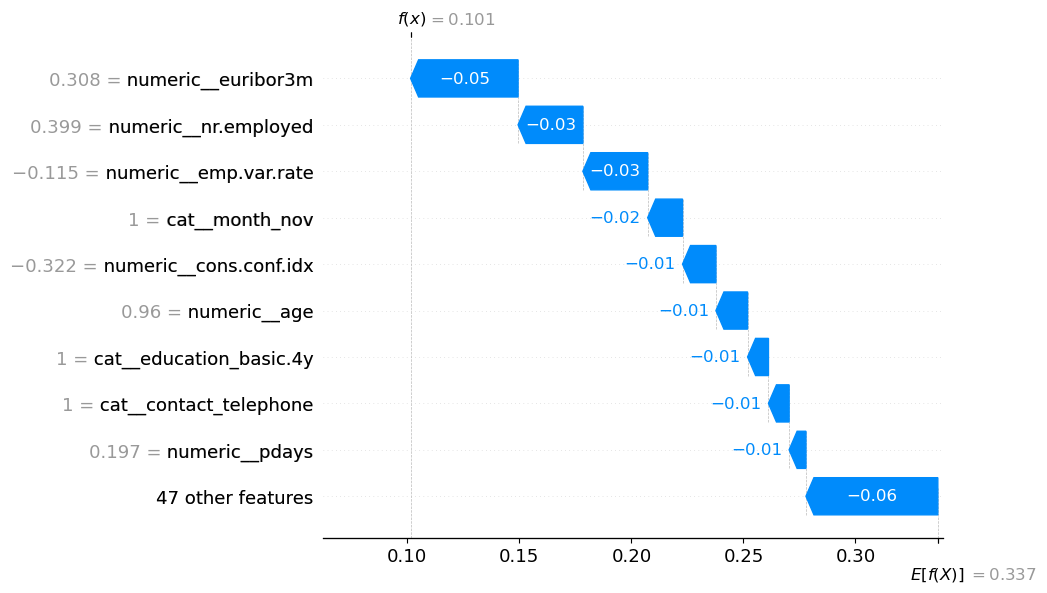


XGBoost, predicted - no


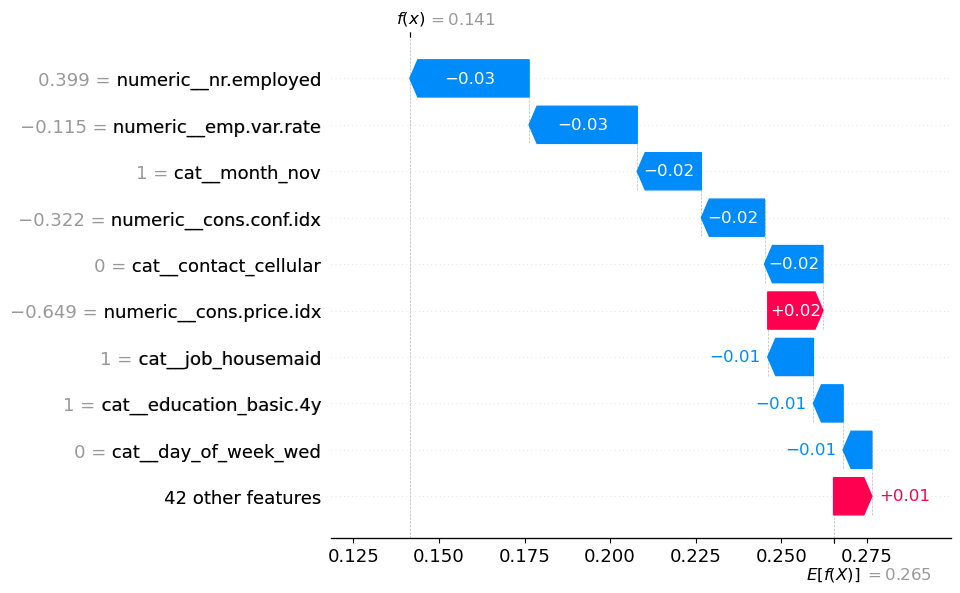


Logistic Regression, predicted - no


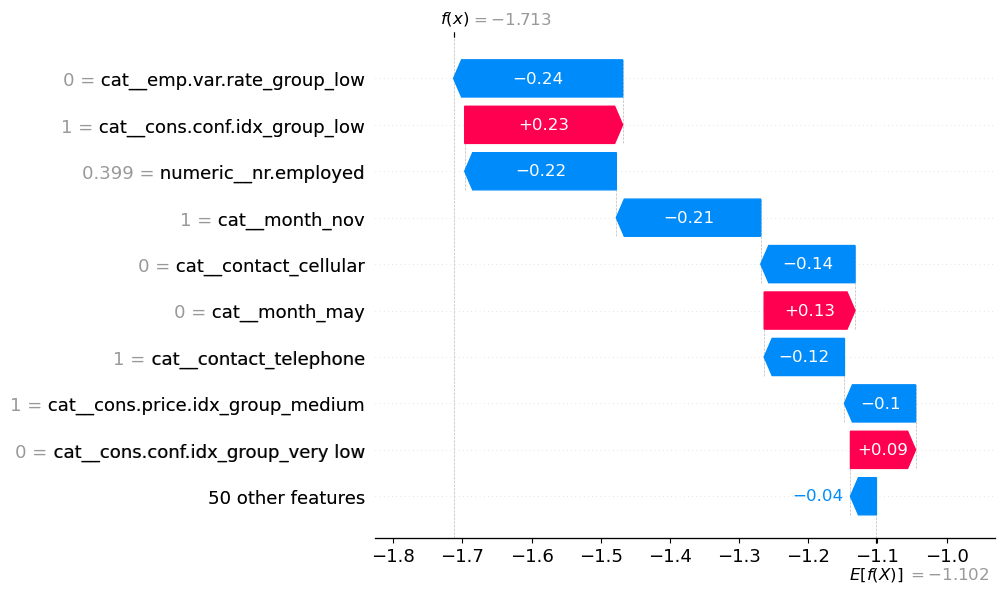

In [32]:
# pick one example
fn_idx = common_fn[0]

plot_shap_waterfall_for_idx(fn_idx)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP Force Plots — False Negative Analysis (Example)**

- Sample Overview
    - True label: "yes"
    - Model prediction: "no" (False Negative)

---

- Baseline vs Prediction
    - Models start from their respective baselines (E[f(x)])
    - Final prediction is pushed toward "no" due to cumulative feature effects
    - Logistic Regression starts from a more negative baseline than RF/XGB

---

- Main Reason for Misclassification
    - Strong negative contributions from macro-economic features dominate:
        - `emp.var.rate`
        - `euribor3m`
        - `nr.employed`
        - `cons.conf.idx`
    - These consistently drive the prediction toward "no"

---

- Competing Signals
    - Some features contribute positively toward "yes"
    - However, their SHAP values are weaker and do not offset the negative drivers

---

- Model-wise Behavior
    - RF: many small contributions → aggregated negative effect
    - XGB: fewer but more pronounced contributors → still dominated by macro features
    - LR: strong linear influence of macro variables → negative push

---

- Key Insight
    - The FN is caused by dominant macro-economic signals outweighing weaker positive indicators
    - The instance lies in a borderline region with conflicting feature effects

---

- Conclusion
    - Misclassification is not due to a single feature
    - It results from consistent dominance of macro-economic variables across all models
    - All models agree on the prediction despite the incorrect outcome

</span>

#### False Positives (FP)


--- Example index: 38241 ---
age                        75
job                   retired
marital               married
education            basic.9y
default                    no
housing                    no
loan                       no
contact              cellular
month                     oct
day_of_week               mon
duration                  120
campaign                    1
pdays                     999
previous                    0
poutcome          nonexistent
emp.var.rate             -3.4
cons.price.idx         92.431
cons.conf.idx           -26.9
euribor3m               0.743
nr.employed            5017.5
y                          no
Name: 38241, dtype: object

Random Forest, predicted - yes


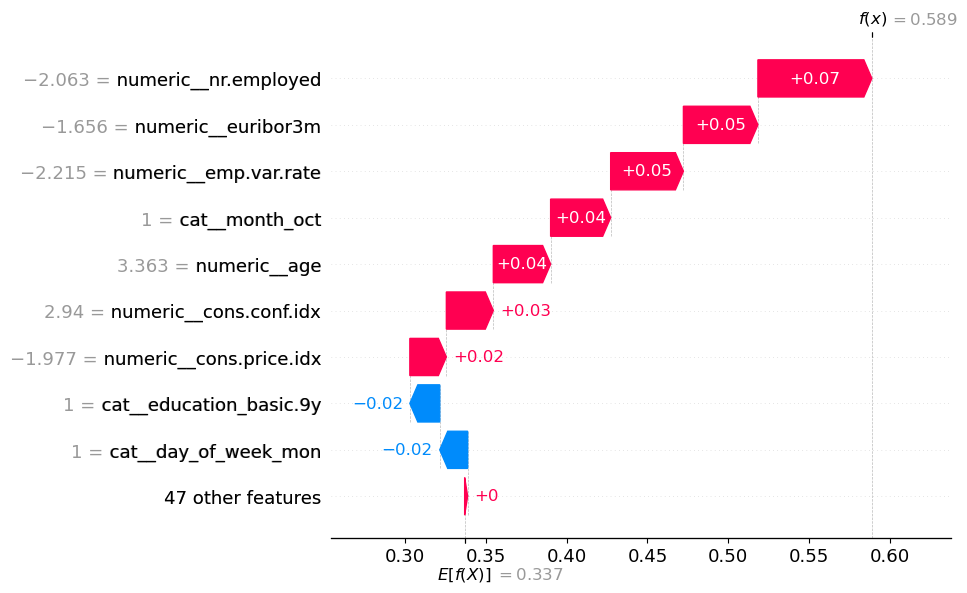


XGBoost, predicted - yes


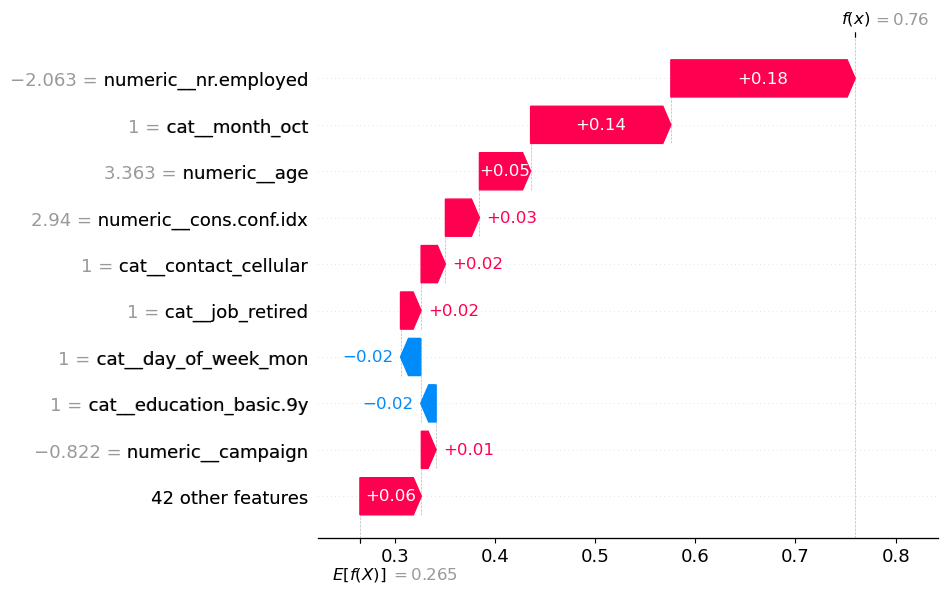


Logistic Regression, predicted - yes


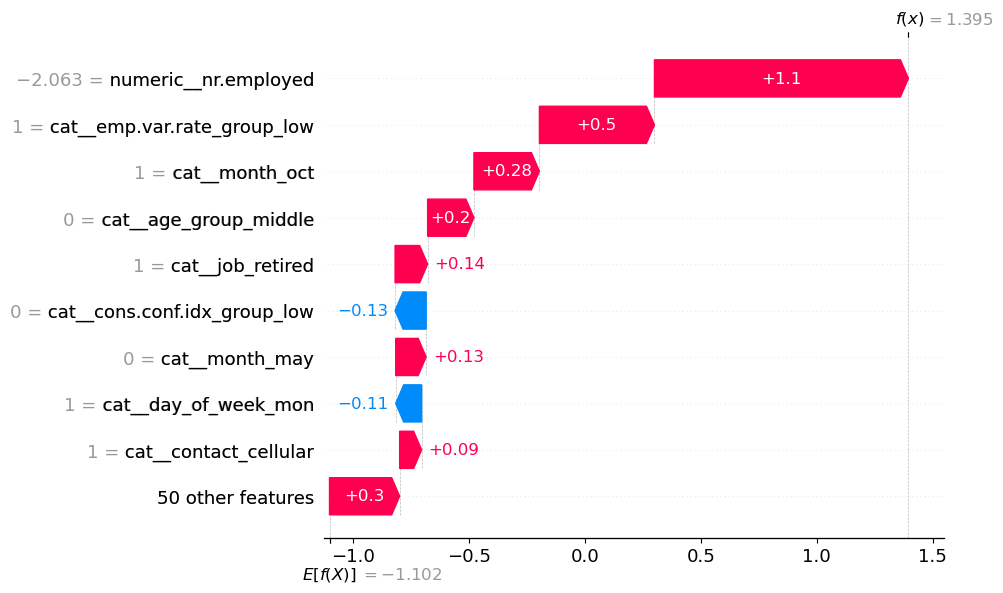

In [33]:
# pick one example
fp_idx = common_fp[0]

plot_shap_waterfall_for_idx(fp_idx)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP Comparison — False Positive Case**

- Sample Overview
    - True label: "no"
    - Model prediction: "yes" (False Positive)
    - All models agree on the incorrect positive prediction

---

- Key Observation
    - Strong feature signals push the instance toward the "yes" class
    - Models overestimate the probability of the positive class

---

- Model Behavior
    - Random Forest:
        - Positive contributions slightly outweigh negatives → "yes"
    - XGBoost:
        - Stronger combined feature effects → confident "yes"
    - Logistic Regression:
        - Linear weights favor positive class → "yes"

---

- Feature-Level Insight
    - Features such as month (october) and macro-economic indicators drive the prediction toward "yes"
    - These patterns resemble typical positive-class behavior
    - All models rely on similar signals, leading to the same mistake

---

- Key Insight
    - Unlike FN cases, the issue is not missing signal but overconfident positive evidence
    - The instance looks like a "yes" case, but the true label is "no"

---

- Conclusion
    - This FP reveals a shared blind spot across models
    - When features strongly resemble positive-class patterns, all models tend to overpredict "yes"
    - Misclassification occurs due to misleading but consistent signals across models

</span>

#### Models mismatch predictions

Analyse examples where different models predicted different target

In [34]:
# find example where xgb and random forest prediction are different
xgb_correct = preds_df[preds_df["xgb"] == preds_df["y_true"]]
xgb_correct_rf_wrong = xgb_correct[xgb_correct["rf"] != xgb_correct["y_true"]]
xgb_correct_rf_wrong

,rf,xgb,lr,y_true
30023,no,yes,no,yes
28321,no,yes,yes,yes



--- Example index: 30023 ---
age                              23
job                          admin.
marital                      single
education         university.degree
default                          no
housing                          no
loan                             no
contact                    cellular
month                           apr
day_of_week                     wed
duration                        314
campaign                          1
pdays                           999
previous                          1
poutcome                    failure
emp.var.rate                   -1.8
cons.price.idx               93.075
cons.conf.idx                 -47.1
euribor3m                     1.405
nr.employed                  5099.1
y                               yes
Name: 30023, dtype: object

Random Forest, predicted - no


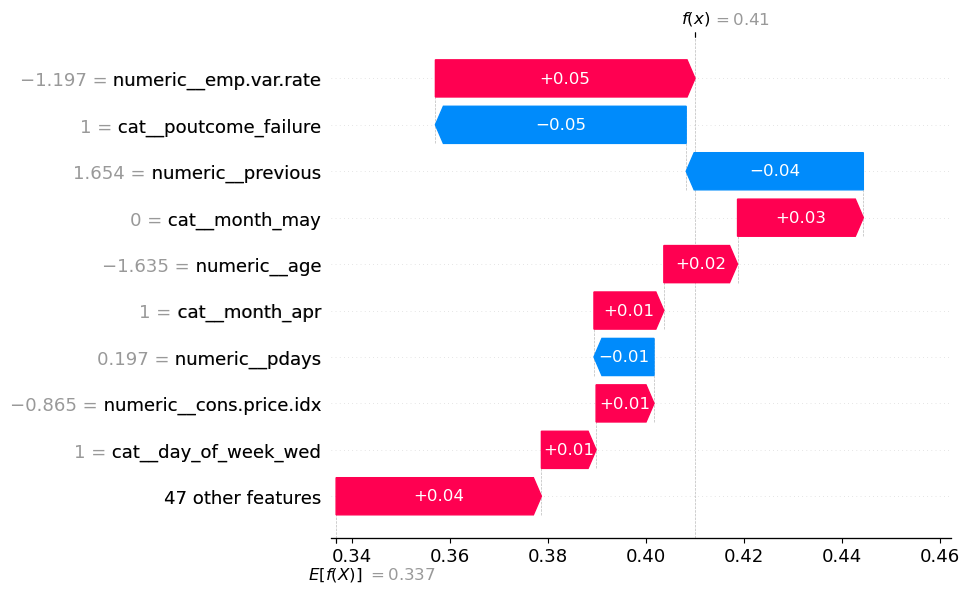


XGBoost, predicted - yes


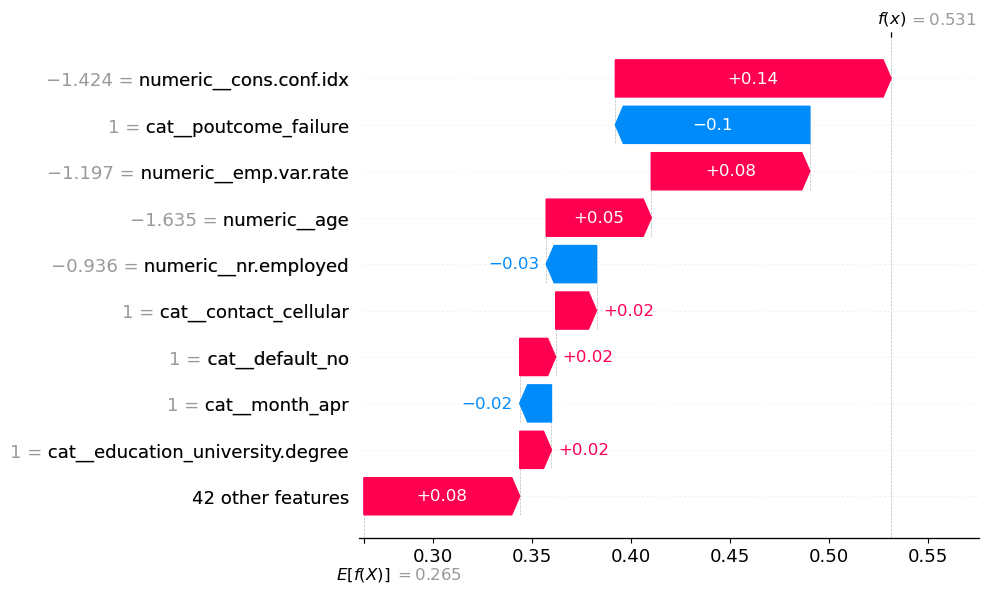


Logistic Regression, predicted - no


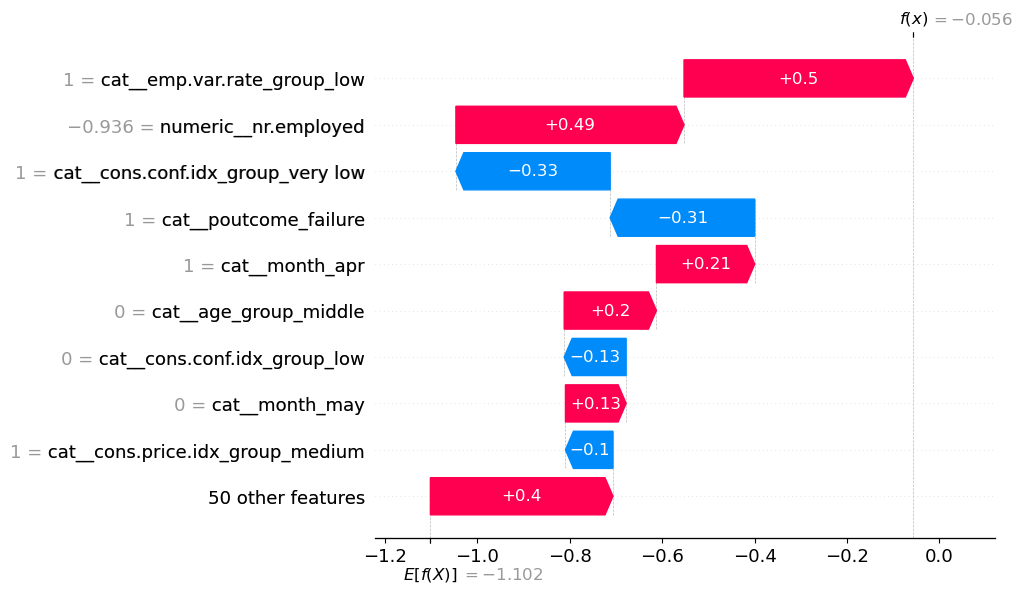

In [35]:
plot_shap_waterfall_for_idx(30023)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP Comparison — Model Disagreement Case (RF vs XGB vs LR)**

- Sample Overview
    - True label: **yes**
    - Random Forest: **no** ❌  
    - XGBoost: **yes** ✅  
    - Logistic Regression: **no** ❌  

    Only XGBoost predicts correctly.

---

- Key Insight
    - This is a borderline case with mixed feature signals, and models differ in how they aggregate them.

---

- Model Behavior
    - Random Forest:
        - Many small positive signals are outweighed by prior campaign features (*poutcome, previous, pdays*), leading to a *no* prediction.
    - XGBoost:
        - Captures stronger combined effects and interactions, correctly pushing the prediction to *yes*.
    - Logistic Regression:
        - Competing linear effects from macro and other features result in a prediction closer to *no*.

---

- Conclusion
    - The disagreement is due to model structure rather than a single feature.  
    - XGBoost better captures feature interactions, while Random Forest and Logistic Regression rely more on aggregation and linear effects, causing them to miss this positive case.

</span>


--- Example index: 28321 ---
age                        35
job                    admin.
marital               married
education         high.school
default                    no
housing                   yes
loan                       no
contact              cellular
month                     apr
day_of_week               wed
duration                 1190
campaign                    1
pdays                     999
previous                    0
poutcome          nonexistent
emp.var.rate             -1.8
cons.price.idx         93.075
cons.conf.idx           -47.1
euribor3m               1.445
nr.employed            5099.1
y                         yes
Name: 28321, dtype: object

Random Forest, predicted - no


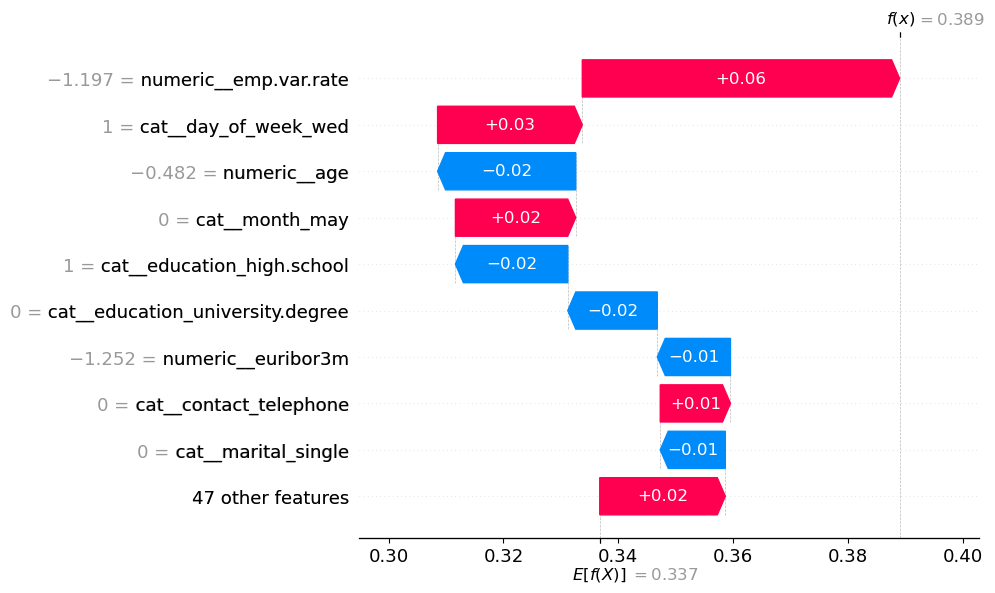


XGBoost, predicted - yes


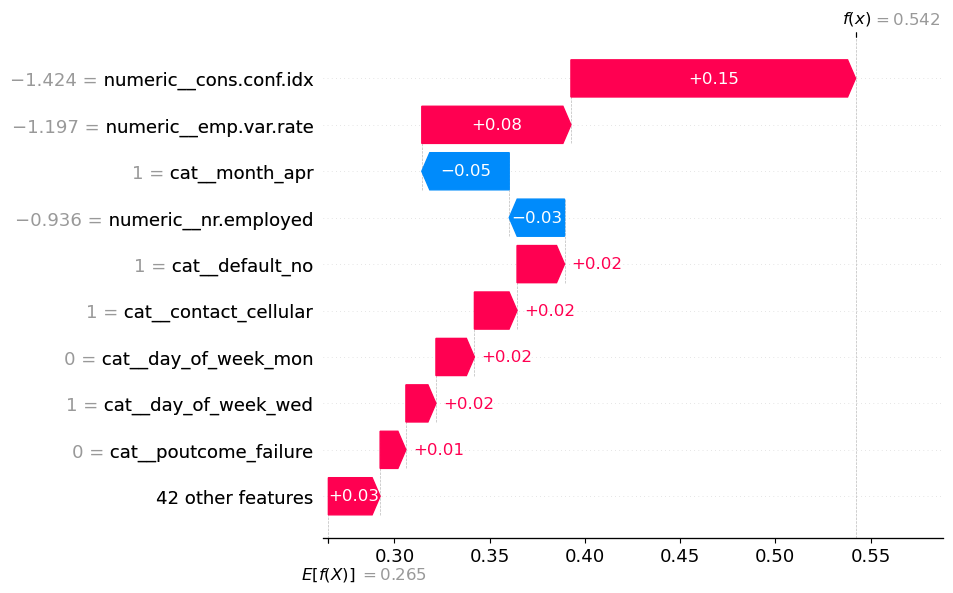


Logistic Regression, predicted - yes


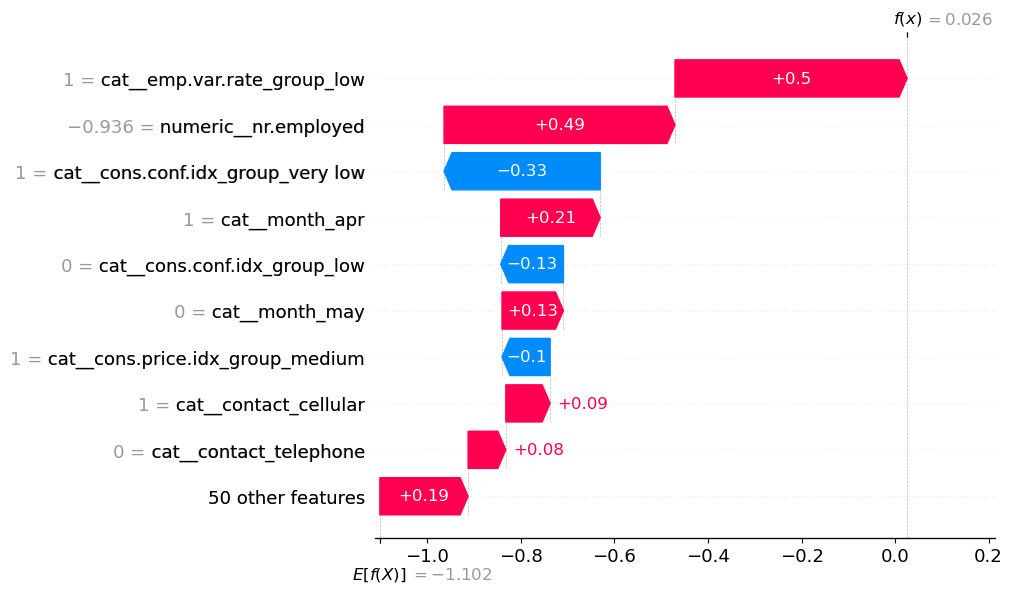

In [36]:
plot_shap_waterfall_for_idx(28321)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP Comparison — Model Disagreement Case (RF vs XGB vs LR)**

- Sample Overview
    - True label: **yes**
    - Random Forest: **no** ❌  
    - XGBoost: **yes** ✅  
    - Logistic Regression: **yes** ✅  

    Only Random Forest misclassifies this instance.

---

- Key Insight
    - This case has stronger positive signals than the previous example.  
    - Models mainly differ in how they aggregate these signals.

---
- Model Behavior

    - **Random Forest**
        - Usually secondary features (e.g., *age, education, marital*) significantly push the prediction toward *no* for this example.

    - **XGBoost**
        - Captures combined effects and interactions; macro-economic features (*cons.conf.idx, emp.var.rate*) strongly support *yes*.

    - **Logistic Regression**
        - Linear feature weights (notably *emp.var.rate* and *nr.employed*) support the *yes* prediction, with minor opposing effects.
---

- Conclusion
    - The positive class is better supported in this case.  
    - Random Forest underestimates combined signals, while XGBoost and Logistic Regression correctly capture the pattern. This is a clearer and easier-to-separate case than the previous one.

</span>

### Error Analysis - Conclusion

<span style="display:block; padding:10px">

**Error Analysis — General Conclusions**

- Overall Observations
    - Models show consistent behavior across similar cases, but differ in how they aggregate feature signals
    - XGBoost is generally more robust in capturing nonlinear interactions
    - Logistic Regression performs well when relationships are approximately linear
    - Random Forest tends to average weaker signals, sometimes missing stronger combined patterns

---

- False Negatives (FN)
    - True "yes" cases predicted as "no"
    - Caused by weak or distributed positive signals
    - Models fail to capture sufficient combined evidence for the positive class
    - Indicates under-sensitivity to the "yes" class

---

- False Positives (FP)
    - True "no" cases predicted as "yes"
    - Driven by strong but misleading patterns resembling the positive class
    - Models become overconfident when similar feature patterns appear

---

- Key Insight
    - Errors are not driven by single features but by how models combine multiple signals
    - FN and FP errors reflect a trade-off between sensitivity and specificity
    - Different model architectures amplify or smooth these effects differently

---

- Model Improvement Ideas
    - Address class imbalance (e.g., class weights, resampling)
    - Optimize decision thresholds instead of default 0.5
    - Tune models explicitly for Recall of the "yes" class (aligned with business needs)
    - Incorporate feature engineering to better separate borderline cases
    - Consider model ensembling to balance strengths of different models

---

- Final Note
    - While models perform reasonably well overall, FN cases suggest that improving Recall for the "yes" class would be beneficial in a business context, even if F1 was used during modeling
    - Current results are acceptable for learning purposes, but further tuning could improve practical performance

</span>